<a href="https://colab.research.google.com/github/aniolarolas/quant-research-pricing-credit-risk/blob/task-01-gas-forecasting/notebooks/01_gas_price_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Investigate and analyze price data - Natural Gas Price Forecasting

[Forage](https://www.theforage.com/simulations/jpmorgan/quantitative-research-11oc)

## 1. Problem Understanding

The objective of this task is to estimate the price of natural gas for a given date using historical market data.

This is relevant for pricing natural gas storage contracts. In this type of contract, a client may inject gas into storage when prices are relatively low and withdraw it later when prices are higher.

The economic value of the storage strategy depends on the difference between the buying price, the selling price, and the costs associated with storing the commodity.

Therefore, before pricing the storage contract itself, we first need a model capable of estimating the natural gas price at any given date.

## 2. Commodity Storage Background

## 3. Time Series Modelling Framework

Let the historical natural gas price series be represented as:

$$
\{(t_i, P_i)\}_{i=1}^{n}
$$

where:

- $t_i$ is the date of observation,
- $P_i$ is the observed natural gas price.

The goal is to build an estimator:

$$
\hat{P}(t) = f(t)
$$

that returns an estimated natural gas price for a given input date $t$.

As an initial modelling framework, we can think of the price series as containing three possible components:

$$
P(t) = T(t) + S(t) + \varepsilon_t
$$

where:

- $T(t)$ represents a long-term trend,
- $S(t)$ represents recurring seasonal behaviour,
- $\varepsilon_t$ represents residual noise.

This is not assumed to be the true market-generating process. It is only a useful exploratory framework to analyse whether the data contains trend and seasonality.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

BASE_dir = Path("/content/drive/MyDrive/quant_research_jpm_jobsim")

RAW_DATA_dir = BASE_dir / "data" / "raw"
PROCESSED_DATA_dir = BASE_dir / "data" / "processed"
BACKUP_dir = BASE_dir / "colab-backup"

print("Base directory: ", BASE_dir)
print("Raw data directory: ", RAW_DATA_dir)
print("Processed data directory ", PROCESSED_DATA_dir)

Base directory:  /content/drive/MyDrive/quant_research_jpm_jobsim
Raw data directory:  /content/drive/MyDrive/quant_research_jpm_jobsim/data/raw
Processed data directory  /content/drive/MyDrive/quant_research_jpm_jobsim/data/processed


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 4. Data Loading


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/quant_research_jpm_jobsim/data/raw/task01/Nat_Gas.csv")

In [ ]:
df["Dates"] = pd.to_datetime(df["Dates"])
df = df.sort_values("Dates")

/tmp/ipykernel_3093/4150226281.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"])


In [ ]:
df.head()
df.tail()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Dates   48 non-null     datetime64[ns]
 1   Prices  48 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 900.0 bytes


## 5. Exploratory Data Analysis


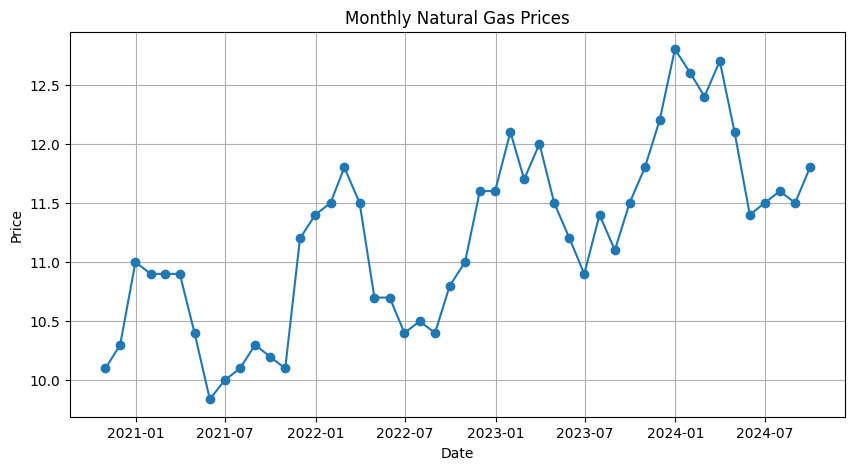

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df["Dates"], df["Prices"], marker="o")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Monthly Natural Gas Prices")
plt.grid(True)
plt.show()

The series shows a clear upward long-term trend. In addition, the price appears to follow a seasonal annual pattern: prices tend to increase during the winter months and decrease during the warmer months. This suggests that both trend and seasonality should be considered in the price estimation model.
**Let's quantificate that!**

### Time Index

To capture the time trend in the series, we create a variable called `time_index`:

$$
t = 0,1,2,\dots,n-1
$$

Each value represents one monthly step in the dataset. This allows us to use time as a numerical input in the model, which is more convenient than working directly with raw dates.

In [ ]:
df["year"] = df["Dates"].dt.year
df["month"] = df["Dates"].dt.month
df["month_name"] = df["Dates"].dt.month_name()
df["time_index"] = np.arange(len(df))

df.head()

,Dates,Prices,year,month,month_name,time_index
0,2020-10-31,10.1,2020,10,October,0
1,2020-11-30,10.3,2020,11,November,1
2,2020-12-31,11.0,2020,12,December,2
3,2021-01-31,10.9,2021,1,January,3
4,2021-02-28,10.9,2021,2,February,4


## 6. Trend and Seasonality Analysis


In [ ]:
monthly_avg = df.groupby("month")["Prices"].mean()
monthly_avg

,Prices
month,
1,11.775
2,11.700
3,11.775
4,11.175
5,10.785
6,10.700
7,10.900
8,10.825
9,11.075


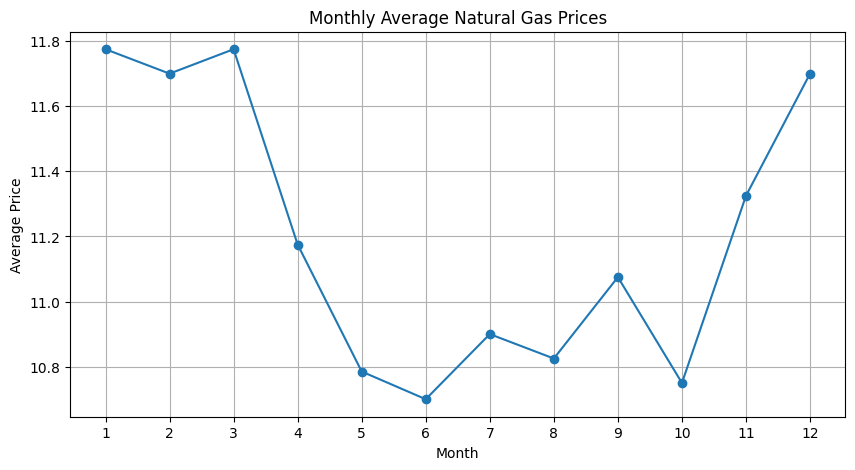

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.title("Monthly Average Natural Gas Prices")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [ ]:
pivot_df = df.pivot(index="month", columns="year", values="Prices")
pivot_df

year,2020,2021,2022,2023,2024
month,,,,,
1,NaN,10.90,11.5,12.1,12.6
2,NaN,10.90,11.8,11.7,12.4
3,NaN,10.90,11.5,12.0,12.7
4,NaN,10.40,10.7,11.5,12.1
5,NaN,9.84,10.7,11.2,11.4
6,NaN,10.00,10.4,10.9,11.5
7,NaN,10.10,10.5,11.4,11.6
8,NaN,10.30,10.4,11.1,11.5
9,NaN,10.20,10.8,11.5,11.8


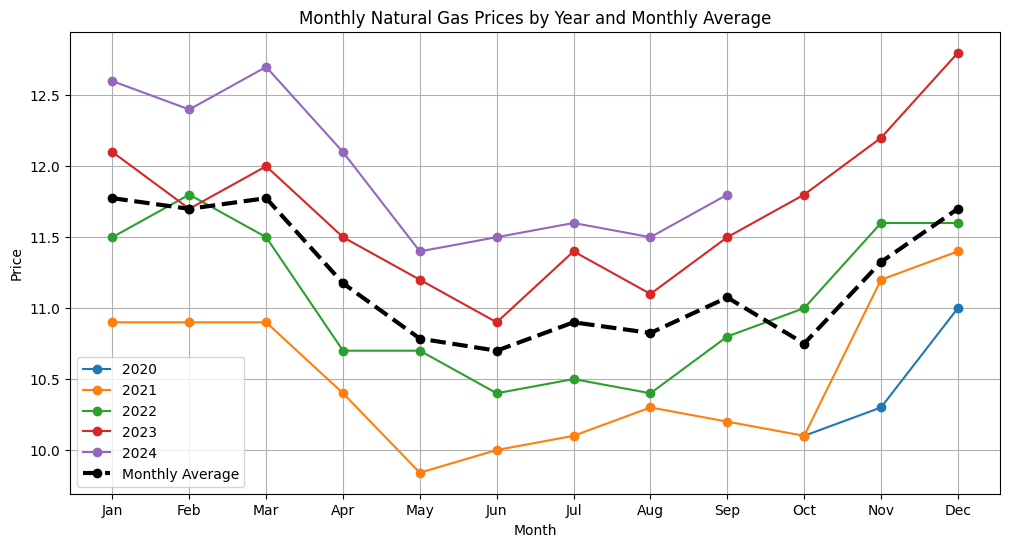

In [ ]:
plt.figure(figsize=(12, 6))

for year in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[year], marker="o", label=str(year))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o",
    linewidth=3,
    color="black",
    linestyle="--",
    label="Monthly Average",
)

plt.xlabel("Month")
plt.ylabel("Price")
plt.title("Monthly Natural Gas Prices by Year and Monthly Average")
plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.legend()
plt.grid(True)
plt.show()

### Seasonality Interpretation

The seasonal comparison suggests that natural gas prices tend to be higher during the winter months and the months closest to winter. This behaviour is economically reasonable because natural gas demand typically increases during colder periods, mainly due to heating needs.

In contrast, prices tend to be lower during the warmer months, when heating demand decreases. This supports the idea that natural gas prices are affected by seasonal demand patterns.

Therefore, the observed seasonality is clear enough to be incorporated into the price estimation model. A model based only on a long-term trend would ignore an important part of the price behaviour, while a model that includes both trend and monthly seasonality should provide more realistic estimates.

## 7. Modelling Strategy

The objective is to estimate the natural gas price for any input date.

The available data contains monthly prices observed at the end of each month. Therefore, the model needs to handle two situations:

1. **Interpolation**: estimating prices for dates between observed historical data points.
2. **Extrapolation**: estimating prices beyond the available data, up to one additional year into the future.

From the exploratory analysis, the series shows:

- a long-term upward trend,
- a seasonal annual pattern,
- higher prices around winter months,
- lower prices during warmer months.

Therefore, a reasonable model should include both a trend component and a seasonal component.

### Trend and Seasonal Regression

The objective of the model is to estimate the natural gas price for any given date. From the exploratory analysis, the price series appears to contain two important behaviours:

1. A **long-term upward trend**, meaning that prices tend to increase over time.
2. A **seasonal annual pattern**, meaning that prices tend to vary depending on the month of the year.

A simple and interpretable way to represent this behaviour is to decompose the estimated price into a trend component and a seasonal component:

$$
\hat{P}(t) = T(t) + S(t)
$$

where:

- $\hat{P}(t)$ is the estimated natural gas price at time $t$,
- $T(t)$ is the long-term trend component,
- $S(t)$ is the seasonal component.

The time variable $t$ is represented by the `time_index` column, where each increase of one unit corresponds to one additional month in the dataset.

#### Trend Component

The trend component captures the general direction of prices over time. A simple way to model this is with a linear trend:

$$
T(t) = \beta_0 + \beta_1 t
$$

where:

- $\beta_0$ is the intercept, representing the baseline price level when $t = 0$,
- $\beta_1$ is the trend coefficient, representing the average monthly increase or decrease in price,
- $t$ is the monthly time index.

If $\beta_1 > 0$, the model captures an upward trend. If $\beta_1 < 0$, it captures a downward trend.

#### Seasonal Component

Natural gas prices often show seasonal behaviour because demand changes throughout the year. For example, demand can increase during colder months due to heating needs.

Since the seasonal pattern repeats approximately every 12 months, we can represent it using sine and cosine functions:

$$
S(t) =
\alpha \sin\left(\frac{2\pi t}{12}\right)
+
\gamma \cos\left(\frac{2\pi t}{12}\right)
$$

where:

- $\sin\left(\frac{2\pi t}{12}\right)$ captures a repeating annual cycle,
- $\cos\left(\frac{2\pi t}{12}\right)$ captures the same cycle with a phase shift,
- $\alpha$ and $\gamma$ determine the size and direction of the seasonal effect.

Using both sine and cosine allows the model to learn not only the strength of the seasonal pattern, but also where the peaks and troughs occur during the year.

#### Full Model

Combining the trend and seasonal components, the final model is:

$$
\hat{P}(t) =
\beta_0
+ \beta_1 t
+ \alpha \sin\left(\frac{2\pi t}{12}\right)
+ \gamma \cos\left(\frac{2\pi t}{12}\right)
$$

This model is appropriate for this task because it is:

- simple and interpretable,
- able to capture the upward trend observed in the data,
- able to represent annual seasonality,
- suitable for extrapolating prices one year beyond the available data.

However, this model is still a simplification. It does not account for unexpected market shocks, geopolitical events, supply disruptions, extreme weather, or changes in storage levels. Therefore, the output should be interpreted as an indicative price estimate rather than a precise market forecast.

## 8. Final Price Estimation Function


## 9. Limitations and Next Steps